# Lab 8


## Setup for SUSY Dataset

Use the SUSY dataset for the rest of this lab. Here is a basic setup.

In [9]:
# Our usual libraries...
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
%matplotlib inline
from IPython.display import HTML, display
import tabulate

In [ ]:
filename="SUSY.csv.zip"
VarNames=["signal", "l_1_pT", "l_1_eta","l_1_phi", "l_2_pT", "l_2_eta", 
          "l_2_phi", "MET", "MET_phi", "MET_rel", "axial_MET",
          "M_R", "M_TR_2", "R", "MT2", "S_R", "M_Delta_R", "dPhi_r_b", "cos_theta_r1"]
df = pd.read_csv(filename, dtype='float64', names=VarNames)

## Scikit-Learn

[Scikit-learn](http://scikit-learn.org) is a rich python library for data science, including machine learning. For example, we can build a Fisher Discriminant (aka Linear Discriminant Analysis, or LDA). 

### Exercise 1: Install Scikit-Learn

Follow the [Installation Instructions](https://scikit-learn.org/stable/install.html) and install `scikit-learn` in your environment.

### Exercise 2: Read About Classifiers

#### Part a
Scikit-learn offers an impressively comprehensive list of machine learning algorithms. Browse through [scikit-learn's documentation](https://scikit-learn.org/stable/index.html). You'll note the algorithms are organized into classification, regression, clustering, dimensionality reduction, model selection, and preprocessing. Browse through the list of [classification algorithms](https://scikit-learn.org/stable/supervised_learning.html#supervised-learning). 

#### Part b
Note scikit-learn's documentation is rather comprehensive. The documentation on [linear models](https://scikit-learn.org/stable/modules/linear_model.html) shows how classification problems are setup. Read about the first few methods and try to comprehend the example codes. Skim the rest of the document.

#### Part c
Read through the [LDA Documentation](https://scikit-learn.org/stable/modules/lda_qda.html).


### Exercise 3: Training a Classifier

Lets' repeat what we did manually in the previous lab using scikit-learn. We'll use a LDA classifier, which we can instanciate as follows:

In [8]:
import sklearn.discriminant_analysis as DA
Fisher=DA.LinearDiscriminantAnalysis()

As discussed in the lecture, to properly formulate our problem, we'll have to:

* Define the inputs (X) vs outputs (Y)
* Designate training vs testing samples (in order to get a unbias assessment of the performance of Machine Learning algorithms)

for example, here we'll take use 4M events for training and the remainder for testing.

In [3]:
N_Train=4000000

Train_Sample=df[:N_Train]
Test_Sample=df[N_Train:]

X_Train=Train_Sample[VarNames[1:]]
y_Train=Train_Sample["signal"]

X_Test=Test_Sample[VarNames[1:]]
y_Test=Test_Sample["signal"]

Test_sig=Test_Sample[Test_Sample.signal==1]
Test_bkg=Test_Sample[Test_Sample.signal==0]


NameError: name 'df' is not defined

We can train the classifier as follow:

In [ ]:
Fisher.fit(X_Train,y_Train)

We can plot the output, comparing signal and background:

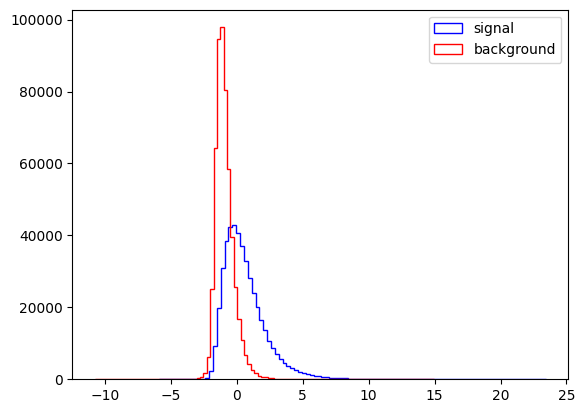

In [6]:
plt.figure()
plt.hist(Fisher.decision_function(Test_sig[VarNames[1:]]),bins=100,histtype="step", color="blue", label="signal",stacked=True)
plt.hist(Fisher.decision_function(Test_bkg[VarNames[1:]]),bins=100,histtype="step", color="red", label="background",stacked=True)
plt.legend(loc='upper right')
plt.show()

#### Part a

Compare ROC curves computed on the test versus training samples, in a single plot. Do you see a bias?

In [11]:
import zipfile
import os

with zipfile.ZipFile("SUSY.csv.zip", "r") as z:
    print(z.namelist())   # shows files inside
    z.extractall()

print(os.listdir())

['supersymmetry_dataset.csv']
['SUSY.csv.zip', 'supersymmetry_dataset.csv', '.ipynb_checkpoints', 'Lab.8.ipynb']


In [13]:
df = pd.read_csv("supersymmetry_dataset.csv", names=VarNames, low_memory=False)

In [15]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
%matplotlib inline

df = pd.read_csv("supersymmetry_dataset.csv", low_memory=False)
print(df.head())
print(df.shape)

   SUSY  lepton 1 pT  lepton 1 eta  lepton 1 phi  lepton 2 pT  lepton 2 eta  \
0   0.0     0.707258      0.613159     -0.763354     1.010814      1.672101   
1   0.0     0.493745     -1.745581     -0.640968     0.576161     -0.514477   
2   1.0     1.305413      0.283820     -1.149154     0.507217     -0.194161   
3   1.0     0.809715     -0.358303     -0.497172     0.787675      0.027419   
4   0.0     0.912852      1.797455     -1.360165     0.496723      1.199644   

   lepton 2 phi  missing energy magnitude  missing energy phi   MET_rel  \
0      1.544314                  0.342641            0.286944  0.514347   
1     -0.629788                  0.585841            0.874038  0.879419   
2      1.313993                  0.659832            0.619593  0.534922   
3      1.201305                  0.790556           -0.861923  0.740287   
4      0.627462                  1.206452           -1.362983  0.033791   

   axial MET       M_R    M_TR_2         R       MT2       S_R  M_Delta_R 

In [16]:
df.columns = ["signal", "l_1_pT", "l_1_eta","l_1_phi", "l_2_pT", "l_2_eta",
              "l_2_phi", "MET", "MET_phi", "MET_rel", "axial_MET",
              "M_R", "M_TR_2", "R", "MT2", "S_R", "M_Delta_R", "dPhi_r_b", "cos_theta_r1"]

In [17]:
df = df.apply(pd.to_numeric, errors="coerce")
df = df.dropna()

In [18]:
import sklearn.discriminant_analysis as DA

VarNames = ["signal", "l_1_pT", "l_1_eta","l_1_phi", "l_2_pT", "l_2_eta",
            "l_2_phi", "MET", "MET_phi", "MET_rel", "axial_MET",
            "M_R", "M_TR_2", "R", "MT2", "S_R", "M_Delta_R", "dPhi_r_b", "cos_theta_r1"]

Fisher = DA.LinearDiscriminantAnalysis()

N_Train = 4000000

Train_Sample = df[:N_Train]
Test_Sample = df[N_Train:]

X_Train = Train_Sample[VarNames[1:]]
y_Train = Train_Sample["signal"]

X_Test = Test_Sample[VarNames[1:]]
y_Test = Test_Sample["signal"]

Fisher.fit(X_Train, y_Train)

print("Model trained")

Model trained


#### Part b

Train the Fisher performance of using the raw, features, and raw+features as input. Compare the performance one a single plot. 

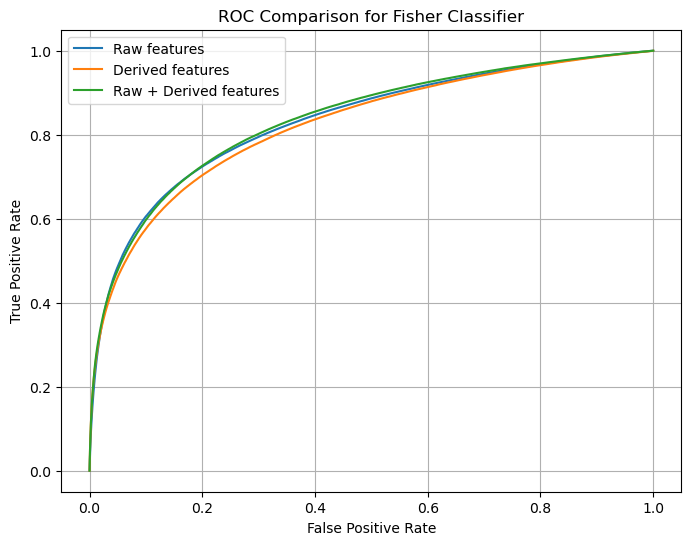

In [19]:
from sklearn.discriminant_analysis import LinearDiscriminantAnalysis
from sklearn.metrics import roc_curve
import matplotlib.pyplot as plt

# raw features = first 8 after signal
raw_vars = VarNames[1:9]

# derived features = remaining 10
feat_vars = VarNames[9:]

# all 18 input features
all_vars = VarNames[1:]

# Training and testing sets for each case
X_Train_raw = Train_Sample[raw_vars]
X_Test_raw = Test_Sample[raw_vars]

X_Train_feat = Train_Sample[feat_vars]
X_Test_feat = Test_Sample[feat_vars]

X_Train_all = Train_Sample[all_vars]
X_Test_all = Test_Sample[all_vars]

# Train models
Fisher_raw = LinearDiscriminantAnalysis()
Fisher_feat = LinearDiscriminantAnalysis()
Fisher_all = LinearDiscriminantAnalysis()

Fisher_raw.fit(X_Train_raw, y_Train)
Fisher_feat.fit(X_Train_feat, y_Train)
Fisher_all.fit(X_Train_all, y_Train)

# Scores
score_raw = Fisher_raw.decision_function(X_Test_raw)
score_feat = Fisher_feat.decision_function(X_Test_feat)
score_all = Fisher_all.decision_function(X_Test_all)

# ROC curves
fpr_raw, tpr_raw, _ = roc_curve(y_Test, score_raw)
fpr_feat, tpr_feat, _ = roc_curve(y_Test, score_feat)
fpr_all, tpr_all, _ = roc_curve(y_Test, score_all)

# Plot
plt.figure(figsize=(8,6))
plt.plot(fpr_raw, tpr_raw, label="Raw features")
plt.plot(fpr_feat, tpr_feat, label="Derived features")
plt.plot(fpr_all, tpr_all, label="Raw + Derived features")

plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Comparison for Fisher Classifier")
plt.legend()
plt.grid()
plt.show()

### Exercise 4: Comparing Techniques

#### Part a
Select 3 different classifiers from the techniques listed [here](http://scikit-learn.org/stable/supervised_learning.html#supervised-learning) to compare. Note that you can use the multi-layer perceptron to build a deep network, though training may be prohibitively slow. So avoid this technique.

#### Part b

Write a function that takes an instantiated classifier and performs the comparison from part 3b. Use the function on your choice of functions in part a.

#### Part c

Use the best method from part c to compute the maximal significance $\sigma_S= \frac{N_S}{\sqrt{N_S+N_B}}$ for the scenarios in lab 5.

In [22]:
from sklearn.linear_model import LogisticRegression
from sklearn.neighbors import KNeighborsClassifier
from sklearn.tree import DecisionTreeClassifier

In [24]:
from sklearn.metrics import roc_curve
import matplotlib.pyplot as plt

def compare_inputs(clf, clf_name):
    raw_vars = VarNames[1:9]
    feat_vars = VarNames[9:]
    all_vars = VarNames[1:]

    X_Train_raw = Train_Sample[raw_vars]
    X_Test_raw = Test_Sample[raw_vars]

    X_Train_feat = Train_Sample[feat_vars]
    X_Test_feat = Test_Sample[feat_vars]

    X_Train_all = Train_Sample[all_vars]
    X_Test_all = Test_Sample[all_vars]

    clf_raw = clf
    clf_feat = clf.__class__(**clf.get_params())
    clf_all = clf.__class__(**clf.get_params())

    clf_raw.fit(X_Train_raw, y_Train)
    clf_feat.fit(X_Train_feat, y_Train)
    clf_all.fit(X_Train_all, y_Train)

    if hasattr(clf_raw, "decision_function"):
        score_raw = clf_raw.decision_function(X_Test_raw)
        score_feat = clf_feat.decision_function(X_Test_feat)
        score_all = clf_all.decision_function(X_Test_all)
    else:
        score_raw = clf_raw.predict_proba(X_Test_raw)[:, 1]
        score_feat = clf_feat.predict_proba(X_Test_feat)[:, 1]
        score_all = clf_all.predict_proba(X_Test_all)[:, 1]

    fpr_raw, tpr_raw, _ = roc_curve(y_Test, score_raw)
    fpr_feat, tpr_feat, _ = roc_curve(y_Test, score_feat)
    fpr_all, tpr_all, _ = roc_curve(y_Test, score_all)

    plt.figure(figsize=(8,6))
    plt.plot(fpr_raw, tpr_raw, label="Raw features")
    plt.plot(fpr_feat, tpr_feat, label="Derived features")
    plt.plot(fpr_all, tpr_all, label="Raw + Derived features")
    plt.xlabel("False Positive Rate")
    plt.ylabel("True Positive Rate")
    plt.title(f"ROC Comparison: {clf_name}")
    plt.legend()
    plt.grid()
    plt.show()

In [ ]:
from sklearn.linear_model import LogisticRegression
from sklearn.neighbors import KNeighborsClassifier
from sklearn.tree import DecisionTreeClassifier

compare_inputs(LogisticRegression(max_iter=1000), "Logistic Regression")
compare_inputs(KNeighborsClassifier(n_neighbors=5), "KNN")
compare_inputs(DecisionTreeClassifier(max_depth=5), "Decision Tree")

In [ ]:
import numpy as np

best_clf = LogisticRegression(max_iter=1000)
best_clf.fit(X_Train, y_Train)

if hasattr(best_clf, "decision_function"):
    scores = best_clf.decision_function(X_Test)
else:
    scores = best_clf.predict_proba(X_Test)[:, 1]

cuts = np.linspace(scores.min(), scores.max(), 200)

best_sigma = 0
best_cut = None

for cut in cuts:
    passed = scores > cut
    NS = np.sum((y_Test == 1) & passed)
    NB = np.sum((y_Test == 0) & passed)

    if NS + NB > 0:
        sigma = NS / np.sqrt(NS + NB)
        if sigma > best_sigma:
            best_sigma = sigma
            best_cut = cut

print("Best cut:", best_cut)
print("Maximum significance:", best_sigma)

### Exercise 5: Metrics

Scikit-learn provides methods for computing the FPR, TPR, ROC, AUC metrics. For example:

In [ ]:
from sklearn.metrics import roc_curve, auc
fpr, tpr, _ = roc_curve(y_Test, Fisher.decision_function(X_Test))

roc_auc = auc(fpr, tpr)

plt.plot(fpr,tpr,color='darkorange',label='ROC curve (area = %0.2f)' % roc_auc)
plt.legend(loc="lower right")
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')

plt.show()


#### Part a
TPR/FPR/ROC/AUC are one way of assessing the quality of a classifier. Read about [Precision and Recall](https://en.wikipedia.org/wiki/Precision_and_recall), [Accuracy](https://en.wikipedia.org/wiki/Accuracy_and_precision), and [F-score](https://en.wikipedia.org/wiki/F-score).

#### Part b
Look through [model evaluation](https://scikit-learn.org/stable/modules/model_evaluation.html#) documentation. Using scikit-learns tools, compute TPR, FPR, ROC, AUC, Precision, Recall, F1 score, and accuracy for the method you selected in 4c above and each scenario. Make a nice table, which also includes the maximal significance. 


In [ ]:
import numpy as np
import pandas as pd
from sklearn.base import clone
from sklearn.metrics import (
    roc_curve, auc,
    precision_score, recall_score, f1_score, accuracy_score,
    confusion_matrix
)

# choose your best classifier from Exercise 4 here
# example:
# from sklearn.linear_model import LogisticRegression
# best_clf = LogisticRegression(max_iter=1000)

raw_vars = VarNames[1:9]
feat_vars = VarNames[9:]
all_vars = VarNames[1:]

scenarios = {
    "Raw only": raw_vars,
    "Derived only": feat_vars,
    "Raw + Derived": all_vars
}

rows = []

for scenario_name, cols in scenarios.items():
    X_train = Train_Sample[cols]
    X_test = Test_Sample[cols]

    clf = clone(best_clf)
    clf.fit(X_train, y_Train)

    # scores for ROC/AUC/significance
    if hasattr(clf, "decision_function"):
        scores = clf.decision_function(X_test)
    else:
        scores = clf.predict_proba(X_test)[:, 1]

    # default class predictions
    y_pred = clf.predict(X_test)

    # ROC + AUC
    fpr, tpr, thresholds = roc_curve(y_Test, scores)
    roc_auc = auc(fpr, tpr)

    # confusion matrix values at default threshold
    tn, fp, fn, tp = confusion_matrix(y_Test, y_pred).ravel()
    tpr_value = tp / (tp + fn)
    fpr_value = fp / (fp + tn)

    # other metrics
    precision = precision_score(y_Test, y_pred)
    recall = recall_score(y_Test, y_pred)
    f1 = f1_score(y_Test, y_pred)
    accuracy = accuracy_score(y_Test, y_pred)

    # maximal significance over score cuts
    cuts = np.linspace(scores.min(), scores.max(), 200)
    best_sigma = 0
    best_cut = None

    for cut in cuts:
        passed = scores > cut
        NS = np.sum((y_Test == 1) & passed)
        NB = np.sum((y_Test == 0) & passed)

        if NS + NB > 0:
            sigma = NS / np.sqrt(NS + NB)
            if sigma > best_sigma:
                best_sigma = sigma
                best_cut = cut

    rows.append({
        "Scenario": scenario_name,
        "TPR": tpr_value,
        "FPR": fpr_value,
        "AUC": roc_auc,
        "Precision": precision,
        "Recall": recall,
        "F1 Score": f1,
        "Accuracy": accuracy,
        "Max Significance": best_sigma,
        "Best Cut": best_cut
    })

results_df = pd.DataFrame(rows)
results_df

In [ ]:
import matplotlib.pyplot as plt
from sklearn.base import clone
from sklearn.metrics import roc_curve, auc

plt.figure(figsize=(8,6))

for scenario_name, cols in scenarios.items():
    X_train = Train_Sample[cols]
    X_test = Test_Sample[cols]

    clf = clone(best_clf)
    clf.fit(X_train, y_Train)

    if hasattr(clf, "decision_function"):
        scores = clf.decision_function(X_test)
    else:
        scores = clf.predict_proba(X_test)[:, 1]

    fpr, tpr, _ = roc_curve(y_Test, scores)
    roc_auc = auc(fpr, tpr)

    plt.plot(fpr, tpr, label=f"{scenario_name} (AUC = {roc_auc:.3f})")

plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curves for Best Classifier")
plt.legend()
plt.grid()
plt.show()